# Advanced Automated Analytical Pipeline

## Business Scenario
A multinational retail company requires a scalable, automated analytical solution to monitor sales, profitability, customer behavior, and operational performance. 

## Project Objectives
The primary goal is to transition from manual ad-hoc analysis to a robust, automated pipeline.
Key objectives include:
*   **Data Cleaning:** Handling missing values, duplicates, and inconsistent formats automatically.
*   **Feature Engineering:** Creating strategic metrics such as `Profit Margin` and `Shipping Duration`.
*   **Memory Optimization:** Downcasting data types for faster processing.
*   **Automated Reporting:** Generating statistical insights, Executive KPI summaries, and advanced visualizations using an Object-Oriented Programming (OOP) approach.

**Dataset Used:** `Sample - Superstore 2019.xlsx`  
**Core Technologies:** Python (Pandas, NumPy, Matplotlib, Seaborn)

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import logging
from datetime import datetime

# Configure logging and visualization style
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
sns.set_theme(style="whitegrid")

---
## 1. Pipeline Architecture & Environment Setup

In the following cell, we define the `SuperstorePipeline` class. By utilizing **Object-Oriented Programming (OOP)**, we ensure our data processing logic is modular, reusable, and easy to maintain.

This class encapsulates all the necessary methods for our workflow: loading data with exception handling, optimizing memory, cleaning anomalies, engineering new features, conducting statistical analysis, and generating visual reports

In [2]:
class SuperstorePipeline:
    """Advanced Automated Pipeline for Superstore Data Analysis."""
    
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None
        
        # Define base directory and dynamic folder name
        base_dir = os.path.dirname(self.file_path)
        folder_name = "Automated_Reports_" + datetime.now().strftime("%Y%m%d")
        self.output_dir = os.path.join(base_dir, folder_name)
        
        if not os.path.exists(self.output_dir):
            os.makedirs(self.output_dir)
            
    def load_and_inspect(self):
        logging.info("Starting data ingestion...")
        try:
            self.df = pd.read_excel(self.file_path)
            logging.info(f"Data loaded successfully. Shape: {self.df.shape}")
        except Exception as e:
            logging.error(f"Error loading data: {e}")
            raise

    def optimize_memory(self):
        for col in self.df.select_dtypes(include=['object']).columns:
            if len(self.df[col].unique()) / len(self.df[col]) < 0.5:
                self.df[col] = self.df[col].astype('category')
        for col in self.df.select_dtypes(include=['float64', 'int64']).columns:
            self.df[col] = pd.to_numeric(self.df[col], downcast='float')
        logging.info("Memory optimization complete.")

    def clean_data(self):
        self.df.drop_duplicates(inplace=True)
        numeric_cols = self.df.select_dtypes(include=['number']).columns
        self.df[numeric_cols] = self.df[numeric_cols].fillna(self.df[numeric_cols].median())
        lower, upper = self.df['Profit'].quantile(0.01), self.df['Profit'].quantile(0.99)
        self.df['Profit'] = np.clip(self.df['Profit'], lower, upper)
        logging.info("Data cleaning complete.")

    def engineer_features(self):
        self.df['Order Date'] = pd.to_datetime(self.df['Order Date'])
        self.df['Ship Date'] = pd.to_datetime(self.df['Ship Date'])
        self.df['Shipping Duration'] = (self.df['Ship Date'] - self.df['Order Date']).dt.days
        self.df['Profit Margin'] = (self.df['Profit'] / self.df['Sales'].replace(0, np.nan)).fillna(0)
        
        bins = [-np.inf, 50, 200, 1000, np.inf]
        labels = ['Low', 'Medium', 'High', 'Premium']
        self.df['Sales Performance Category'] = pd.cut(self.df['Sales'], bins=bins, labels=labels)
        logging.info("Feature engineering complete.")

    def generate_automated_report(self):
        total_sales = self.df['Sales'].sum()
        total_profit = self.df['Profit'].sum()
        avg_margin = self.df['Profit Margin'].mean() * 100
        
        report = f"""
        =========================================
        AUTOMATED EXECUTIVE KPI REPORT
        =========================================
        - Total Revenue: ${total_sales:,.2f}
        - Total Profit: ${total_profit:,.2f}
        - Average Profit Margin: {avg_margin:.2f}%
        - Total Orders Processed: {len(self.df)}
        =========================================
        """
        print(report)

    def run_data_prep(self):
        """Runs the ETL process without plotting."""
        self.load_and_inspect()
        self.optimize_memory()
        self.clean_data()
        self.engineer_features()
        self.generate_automated_report()
        # Exporting clean data
        self.df.to_csv(f"{self.output_dir}/Cleaned_Superstore_Data.csv", index=False)
        logging.info(f"Data Prep complete! CSV saved to: {self.output_dir}")

# Modular visualization methods

    def plot_sales_trend(self):
        plt.figure(figsize=(10, 4))
        monthly_sales = self.df.set_index('Order Date').resample('ME')['Sales'].sum()
        sns.lineplot(data=monthly_sales, color='blue', linewidth=2)
        plt.title('1. Monthly Sales Trend (2019)')
        plt.ylabel('Total Sales')
        plt.savefig(f"{self.output_dir}/1_Monthly_Sales_Trend.png", bbox_inches='tight')
        plt.show()

    def plot_profit_by_category(self):
        plt.figure(figsize=(10, 4))
        sns.barplot(data=self.df, x='Sub-Category', y='Profit', estimator=sum, errorbar=None, hue='Category')
        plt.xticks(rotation=45)
        plt.title('2. Total Profit by Sub-Category')
        plt.savefig(f"{self.output_dir}/2_Profit_by_SubCategory.png", bbox_inches='tight')
        plt.show()

    def plot_profit_margin_dist(self):
        plt.figure(figsize=(8, 4))
        sns.histplot(self.df['Profit Margin'], bins=50, kde=True, color='purple')
        plt.title('3. Distribution of Profit Margins')
        plt.savefig(f"{self.output_dir}/3_Profit_Margin_Distribution.png", bbox_inches='tight')
        plt.show()

    def plot_sales_vs_profit(self):
        plt.figure(figsize=(8, 4))
        sns.scatterplot(data=self.df, x='Sales', y='Profit', hue='Region', alpha=0.6)
        plt.title('4. Sales vs Profit by Region')
        plt.savefig(f"{self.output_dir}/4_Sales_vs_Profit.png", bbox_inches='tight')
        plt.show()

    def plot_shipping_duration(self):
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=self.df, x='Ship Mode', y='Shipping Duration', palette='Set2')
        plt.title('5. Shipping Duration Analysis')
        plt.savefig(f"{self.output_dir}/5_Shipping_Duration.png", bbox_inches='tight')
        plt.show()

    def plot_sales_category(self):
        plt.figure(figsize=(8, 4))
        sns.countplot(data=self.df, x='Sales Performance Category', palette='viridis')
        plt.title('6. Transactions by Sales Performance Category')
        plt.savefig(f"{self.output_dir}/6_Sales_Performance_Category.png", bbox_inches='tight')
        plt.show()

    def plot_top_cities(self):
        plt.figure(figsize=(10, 6))
        top_cities = self.df.groupby('City', observed=True)['Sales'].sum().nlargest(10).reset_index()
        top_cities['City'] = top_cities['City'].astype(str)
        sns.barplot(data=top_cities, y='City', x='Sales', hue='City', palette='magma', legend=False)
        plt.title('7. Top 10 Cities by Revenue')
        plt.xlabel('Total Sales ($)')
        plt.ylabel('City')
        plt.savefig(f"{self.output_dir}/7_Top_Cities_Revenue.png", bbox_inches='tight')
        plt.show()

    def plot_correlation_matrix(self):
        plt.figure(figsize=(8, 5))
        numeric_df = self.df.select_dtypes(include=['number'])
        sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
        plt.title('8. Statistical Correlation Matrix')
        plt.savefig(f"{self.output_dir}/8_Correlation_Matrix.png", bbox_inches='tight')
        plt.show()

---
## 2. Pipeline Execution & Data Validation

With our architecture defined, we will now instantiate the pipeline and pass our dataset

The pipeline will automatically clean the data, print the Executive KPI Report, and export the finalized dataset to our output directory

In [3]:
# Initialize and run data preparation (ETL)
file_name = r"F:\Projects\DEPI\Advanced Automated Analytical Pipeline\Sample - Superstore 2019.xlsx"

analyzer = SuperstorePipeline(file_path=file_name)
analyzer.run_data_prep()

# Display the first 3 rows to validate
analyzer.df.head(3)

INFO: Starting data ingestion...
c:\Users\mosta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
INFO: Data loaded successfully. Shape: (9994, 21)
C:\Users\mosta\AppData\Local\Temp\ipykernel_16196\2726824787.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in self.df.select_dtypes(include=['object']).columns:
INFO: Memory optimization complete.
INFO: Data cleaning complete.
INFO: Feat


        AUTOMATED EXECUTIVE KPI REPORT
        - Total Revenue: $2,297,200.86
        - Total Profit: $262,912.48
        - Average Profit Margin: 12.29%
        - Total Orders Processed: 9994
        


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Duration,Profit Margin,Sales Performance Category
0,1.0,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2.0,0.0,41.913601,3,0.16,High
1,2.0,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3.0,0.0,219.582001,3,0.30,High
2,3.0,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,0.0,6.871400,4,0.47,Low


---
## 3. EDA & Visual Insights
In this section, we generate 8 individual visualizations to uncover trends and patterns in the data

### 1. Monthly Sales Trend
This visualization helps us understand the seasonality of our sales throughout the year

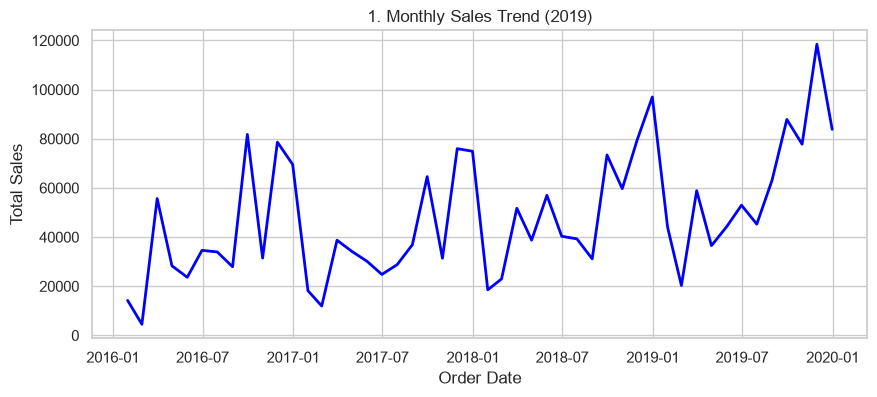

In [4]:
analyzer.plot_sales_trend()

### 2. Profit by Sub-Category
Identifying which product categories drive our profit margins and which operate at a loss

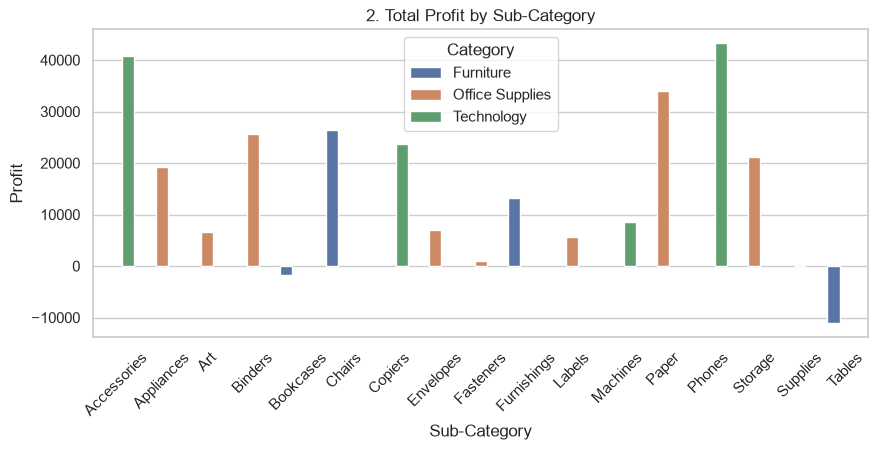

In [5]:
analyzer.plot_profit_by_category()

### 3. Profit Margin Distribution
Understanding the frequency and spread of our profit margins across all transactions

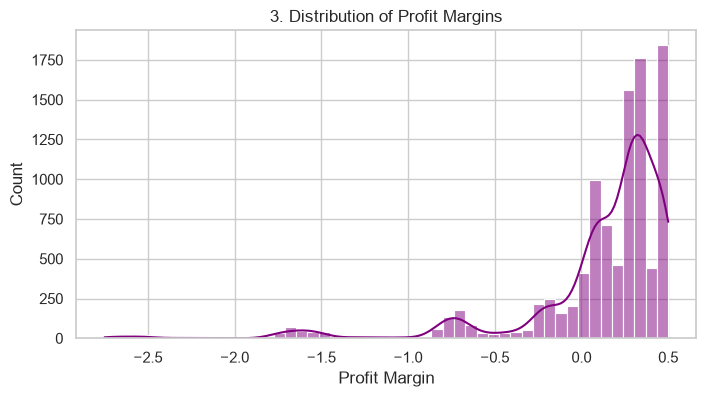

In [6]:
analyzer.plot_profit_margin_dist()

### 4. Sales vs Profit by Region
A scatter plot analyzing the relationship between revenue and profit across different geographical regions

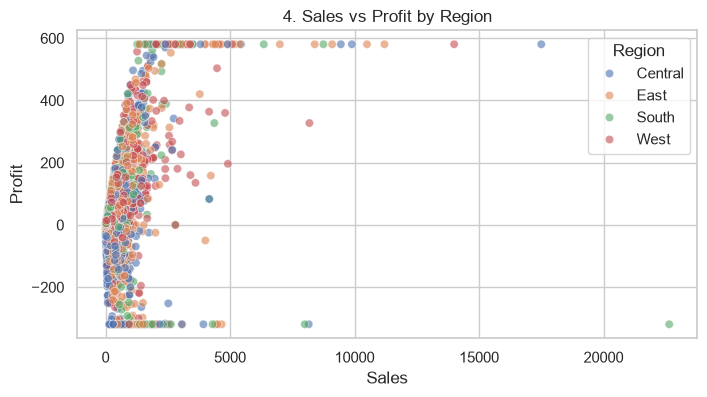

In [7]:
analyzer.plot_sales_vs_profit()

### 5. Shipping Duration Analysis
Evaluating the efficiency of our logistics by comparing shipping modes against delivery duration

C:\Users\mosta\AppData\Local\Temp\ipykernel_16196\2726824787.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=self.df, x='Ship Mode', y='Shipping Duration', palette='Set2')


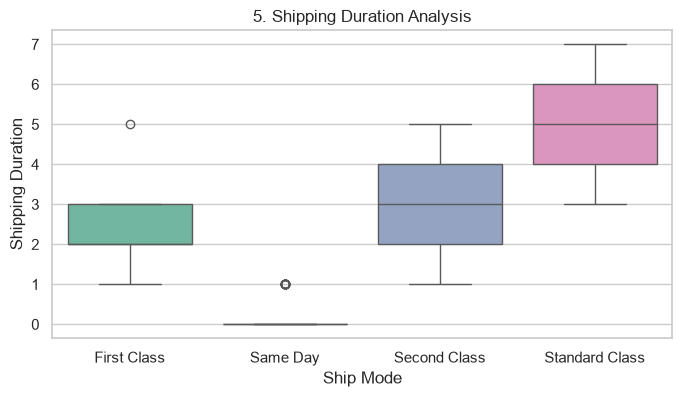

In [8]:
analyzer.plot_shipping_duration()

### 6. Sales Performance Category Breakdown
Categorizing transactions (Low / Medium / High / Premium) to understand our typical order sizes

C:\Users\mosta\AppData\Local\Temp\ipykernel_16196\2726824787.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=self.df, x='Sales Performance Category', palette='viridis')


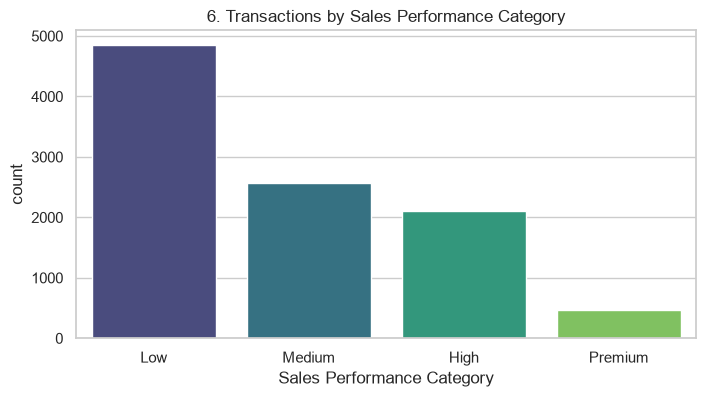

In [9]:
analyzer.plot_sales_category()

### 7. Top 10 Cities by Revenue
Highlighting our most profitable urban markets based on total sales

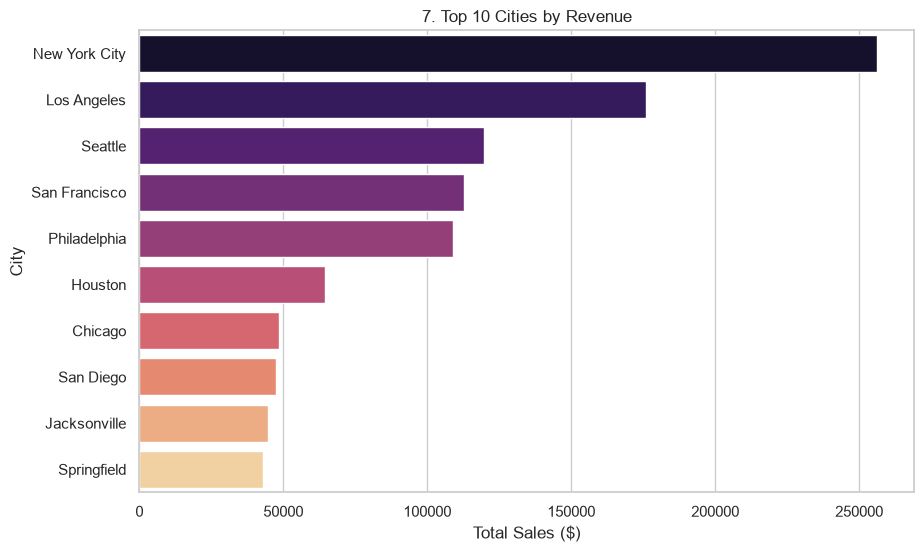

In [10]:
analyzer.plot_top_cities()

### 8. Statistical Correlation Matrix
A heatmap to identify strong positive or negative correlations between numerical features (e.g., Sales, Profit, Discount)

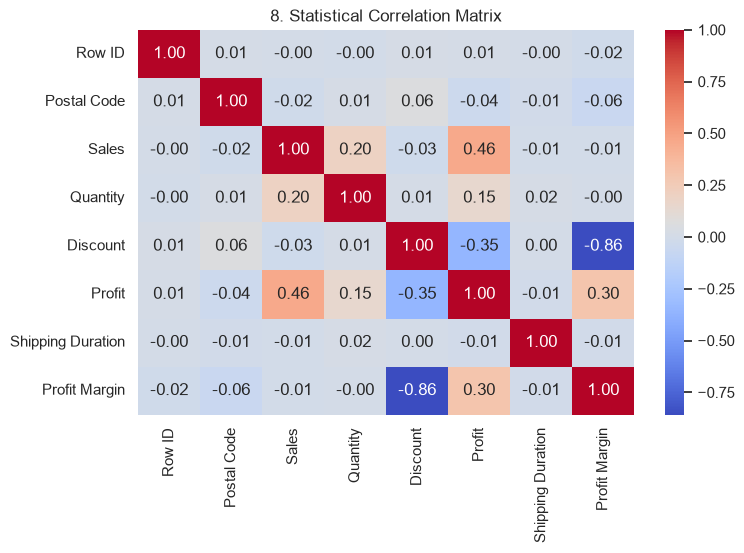

In [11]:
analyzer.plot_correlation_matrix()

---
## 4. Executive Summary & Strategic Recommendations

### Key Findings
Through our automated pipeline, we successfully processed and analyzed the Superstore dataset. 
*   **Seasonality:** Sales volume exhibits a strong positive trend towards the end of the year (Q4), likely driven by holiday shopping.
*   **Profitability Gap:** While the *Technology* category is highly lucrative, certain items in the *Furniture* category—specifically **Tables**—are consistently operating at a significant net loss, dragging down overall profitability.
*   **Operational Insights:** The correlation matrix reveals that heavy discounts strongly negatively correlate with profit, suggesting current discount strategies are cannibalizing margins.

### Business Recommendations
1.  **Restructure Furniture Pricing:** Conduct an immediate pricing and supply chain review for "Tables". Consider discontinuing heavily discounted items or renegotiating supplier contracts.
2.  **Optimize Discount Strategy:** Since discounts severely impact profit margins without proportionally driving up overall sales value, the company should cap maximum discount percentages.
3.  **Capitalize on Q4 Demand:** Allocate a higher marketing budget and increase inventory for top-performing *Technology* and *Office Supplies* ahead of the Q4 rush.

### Future Work & Next Steps
To further enhance this analytical solution, the next iterations of this project could include:
1.  **Machine Learning Integration:** Implementing a Time-Series forecasting model (such as ARIMA or Facebook Prophet) to predict future sales and optimize inventory management.
2.  **Interactive Dashboards:** Transitioning these static findings into a fully interactive Power BI or Streamlit dashboard for real-time stakeholder monitoring.